# Notebook 01 — Corpus Acquisition & Two-Layer Dictionary

**Project:** SciSpell — a domain-aware spelling correction system for scientific text
**Stage:** Foundation — building the corpus and dictionary every later component depends on

---

## Purpose of this notebook

Every spelling corrector needs two things before any correction logic can exist:

1. **A corpus** — a large body of real text in our chosen domain. From it we learn
   *which words exist* and *how often each one is used*. A reliable frequency model needs scale — we target **at least 100,000 words**.
2. **A dictionary** — the list of words the system will treat as correctly spelled.

### Our domain: Science

We assemble a **~235,000-word science corpus** from three public-domain classics
(biology, physics, chemistry), downloaded and processed fully inside this notebook
for reproducibility.

### The two-layer dictionary design

A known failure mode of small dictionaries is **flagging correct words as errors**
(false positives). We prevent this with two layers:

| Layer | Source | Size | Role |
|---|---|---|---|
| **Domain layer** | Our science corpus | ~15–20k unique words | Word **frequencies** → used to *rank* correction candidates |
| **Coverage layer** | General English wordlist | ~370k words | Word **existence** → used to *detect* whether a word is an error |

A word is only flagged as a misspelling if it appears in **neither** layer.
Frequencies for ranking always come from the domain layer, so corrections stay
science-flavoured.

### Outputs saved for later notebooks

- `data/science_corpus.txt` — the cleaned corpus
- `data/word_freq.json` — domain word frequencies
- `data/dictionary.txt` — the merged two-layer vocabulary
- `data/corpus_metadata.json` — sources, counts, citations

In [1]:
# ── Environment setup ─────────────────────────────────────────────
import sys
import re
import json
import urllib.request
from pathlib import Path
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt

# ── Project paths ──
# The notebook lives in NLP/notebooks/, data artefacts live in NLP/data/.
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python      : {sys.version.split()[0]}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Data dir    : {DATA_DIR.resolve()}")

Python      : 3.11.15
Matplotlib  : 3.10.9
Project root: /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP
Data dir    : /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/data


## 1. Corpus Acquisition

### Source selection criteria

1. **Domain fit** — canonical science writing (biology, physics, chemistry)
2. **Legality** — public domain, so we may redistribute the corpus with the project
3. **Reproducibility** — fetched programmatically from stable Project Gutenberg URLs
4. **Size** — combined total must exceed our 100,000-word design target

### Selected texts

| # | Author | Title | Field | Year | Gutenberg ID |
|---|--------|-------|-------|------|--------------|
| 1 | Charles Darwin | *On the Origin of Species* (1st ed.) | Biology | 1859 | 1228 |
| 2 | Albert Einstein | *Relativity: The Special and General Theory* | Physics | 1920 | 30155 |
| 3 | Michael Faraday | *The Chemical History of a Candle* | Chemistry | 1861 | 14474 |

### Citations

- Darwin, C. (1859). *On the Origin of Species by Means of Natural Selection*.
  London: John Murray. Retrieved from Project Gutenberg (EBook #1228),
  https://www.gutenberg.org/ebooks/1228
- Einstein, A. (1920). *Relativity: The Special and General Theory*
  (R. W. Lawson, Trans.). London: Methuen & Co. Retrieved from Project Gutenberg
  (EBook #5001), https://www.gutenberg.org/ebooks/30155
- Faraday, M. (1861). *The Chemical History of a Candle*. London: Griffin, Bohn & Co.
  Retrieved from Project Gutenberg (EBook #14474),
  https://www.gutenberg.org/ebooks/14474

### Cleaning applied

Every Project Gutenberg file wraps the actual book in **boilerplate** — a licence
header before the text and a licence footer after it, marked by lines containing
`*** START OF ...` and `*** END OF ...`. We strip everything outside those markers
so licence text does not pollute our word frequencies.

In [2]:
# ── Download the three source texts from Project Gutenberg ────────
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(exist_ok=True)

BOOKS = [
    {"id": 1228,  "author": "Charles Darwin",  "title": "On the Origin of Species (1st ed.)",          "field": "Biology"},
    {"id": 30155, "author": "Albert Einstein", "title": "Relativity: The Special and General Theory",  "field": "Physics"},
    {"id": 14474, "author": "Michael Faraday", "title": "The Chemical History of a Candle",            "field": "Chemistry"},
]

# Gutenberg serves plain-text under two common URL patterns; we try both.
URL_PATTERNS = [
    "https://www.gutenberg.org/cache/epub/{id}/pg{id}.txt",
    "https://www.gutenberg.org/files/{id}/{id}-0.txt",
]

def download_book(book_id: int) -> str:
    """Download one Gutenberg book as raw text, using a local cache."""
    cache_file = RAW_DIR / f"pg{book_id}.txt"
    if cache_file.exists():
        print(f"  cached   → {cache_file.name}")
        return cache_file.read_text(encoding="utf-8")

    last_error = None
    for pattern in URL_PATTERNS:
        url = pattern.format(id=book_id)
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as resp:
                raw = resp.read().decode("utf-8", errors="replace")
            cache_file.write_text(raw, encoding="utf-8")
            print(f"  download → {url}")
            return raw
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not download book {book_id}: {last_error}")

def strip_gutenberg_boilerplate(raw: str) -> str:
    """Keep only the text between the *** START *** and *** END *** markers."""
    start = re.search(r"\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG.*?\*\*\*", raw, re.IGNORECASE)
    end   = re.search(r"\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG.*?\*\*\*",   raw, re.IGNORECASE)
    body = raw[start.end() if start else 0 : end.start() if end else len(raw)]
    return body.strip()

book_texts = {}
for book in BOOKS:
    print(f"{book['author']} — {book['title']}")
    raw  = download_book(book["id"])
    body = strip_gutenberg_boilerplate(raw)
    book_texts[book["id"]] = body
    approx_words = len(body.split())
    print(f"  cleaned  → {len(body):,} characters, ~{approx_words:,} words\n")

total_words = sum(len(t.split()) for t in book_texts.values())
print(f"TOTAL (approximate, before tokenization): ~{total_words:,} words")
print(f"Design target (100,000 words): {'MET ✓' if total_words >= 100_000 else 'NOT MET ✗'}")

Charles Darwin — On the Origin of Species (1st ed.)
  cached   → pg1228.txt
  cleaned  → 932,990 characters, ~155,526 words

Albert Einstein — Relativity: The Special and General Theory
  cached   → pg30155.txt
  cleaned  → 185,570 characters, ~31,077 words

Michael Faraday — The Chemical History of a Candle
  cached   → pg14474.txt
  cleaned  → 222,486 characters, ~41,712 words

TOTAL (approximate, before tokenization): ~228,315 words
Design target (100,000 words): MET ✓


In [3]:
# ── Assemble the combined corpus and save artefacts ───────────────
CORPUS_PATH = DATA_DIR / "science_corpus.txt"
META_PATH   = DATA_DIR / "corpus_metadata.json"

sections = []
metadata_books = []

for book in BOOKS:
    body = book_texts[book["id"]]
    banner = f"\n\n{'=' * 70}\n== {book['author']} — {book['title']}\n{'=' * 70}\n\n"
    sections.append(banner + body)
    metadata_books.append({
        "gutenberg_id": book["id"],
        "author":       book["author"],
        "title":        book["title"],
        "field":        book["field"],
        "source_url":   f"https://www.gutenberg.org/ebooks/{book['id']}",
        "characters":   len(body),
        "approx_words": len(body.split()),
    })

corpus_text = "".join(sections).strip()
CORPUS_PATH.write_text(corpus_text, encoding="utf-8")

metadata = {
    "project":       "SciSpell — domain-aware spelling correction",
    "domain":        "Science (biology, physics, chemistry)",
    "created":       "2026-08-03",
    "licence":       "Source texts are public domain (Project Gutenberg)",
    "books":         metadata_books,
    "total_characters":   len(corpus_text),
    "total_approx_words": sum(b["approx_words"] for b in metadata_books),
}
META_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Corpus saved   → {CORPUS_PATH}  ({len(corpus_text):,} characters)")
print(f"Metadata saved → {META_PATH}")
print(f"\nApprox. words in combined corpus: {metadata['total_approx_words']:,}")

Corpus saved   → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/data/science_corpus.txt  (1,341,652 characters)
Metadata saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/data/corpus_metadata.json

Approx. words in combined corpus: 228,315


## 2. Tokenization

**Tokenization** is the step that turns one giant string of text into a list of
individual words (**tokens**). Everything downstream — frequencies, the dictionary,
the language model — counts tokens, so the rules we choose here define what a
"word" means for the entire system.

Two terms used throughout this project:

- **Token** — every occurrence of a word. "the cat saw the dog" → 5 tokens.
- **Type**  — every *distinct* word. The same sentence has 4 types
  (*the* appears twice).

### Our tokenization rules

| Rule | Reason |
|---|---|
| Lowercase everything | "The" and "the" are the same word; merging them makes frequency counts honest. A spelling checker also shouldn't treat capitalization as a spelling difference. |
| Keep only alphabetic sequences | Numbers, punctuation, and the `===` book banners are not candidate dictionary words. |
| Allow one internal apostrophe (`don't`, `it's`, `nature's`) | These are real words users type; splitting them would create fake fragments like *don* and *t*. |
| No stemming or lemmatization | A dictionary must contain the *actual surface forms* people spell — *species*, *evolved*, *evolving* are all separately valid spellings. |

The regex implementing this: `[a-z]+(?:'[a-z]+)?` — one or more letters,
optionally followed by an apostrophe and more letters.

In [4]:
# ── Tokenizer and official corpus statistics ──────────────────────
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text: str) -> list[str]:
    """Lowercase the text and return alphabetic tokens (internal apostrophes kept)."""
    return TOKEN_RE.findall(text.lower())

tokens = tokenize(corpus_text)
word_freq = Counter(tokens)

n_tokens = len(tokens)          # total words   (corpus size)
n_types  = len(word_freq)       # unique words  (vocabulary size)

print(f"Corpus size (tokens) : {n_tokens:,}")
print(f"Vocabulary  (types)  : {n_types:,}")
print(f"Type/token ratio     : {n_types / n_tokens:.4f}")
print(f"\nDesign target ≥ 100,000 tokens: {'MET ✓' if n_tokens >= 100_000 else 'NOT MET ✗'}")

print("\nTop 15 most frequent words:")
for word, count in word_freq.most_common(15):
    print(f"  {word:<10} {count:>7,}")

Corpus size (tokens) : 229,325
Vocabulary  (types)  : 8,895
Type/token ratio     : 0.0388

Design target ≥ 100,000 tokens: MET ✓

Top 15 most frequent words:
  the         16,301
  of          11,476
  and          6,186
  in           5,600
  to           5,423
  a            4,372
  that         3,210
  is           2,852
  it           2,367
  have         2,300
  as           2,270
  be           2,113
  we           2,088
  which        2,053
  by           1,971


## 3. The Two-Layer Dictionary

### The problem a single-source dictionary has

Our corpus vocabulary (~8.9k types) knows science words well, but a user typing
*pizza*, *keyboard*, or *jealous* would be told those are spelling errors —
**false positives**, the most annoying failure a spell checker can have.

### The design

| Layer | Contents | Question it answers |
|---|---|---|
| **Domain layer** | Corpus `word_freq` (~8.9k types with counts) | *"How probable is this word?"* → ranks correction candidates |
| **Coverage layer** | Large general-English wordlist | *"Does this word exist at all?"* → decides whether to flag |

A typed word is flagged as a non-word error **only if it appears in neither layer**.

### Coverage-layer source

We use the **dwyl `english-words`** list (`words_alpha.txt`, ~370k entries), a
widely used open dataset derived from the public-domain *Moby Words* project.

> Citation: dwyl (n.d.). *english-words: A text file containing over 466k English
> words* [Data set]. GitHub. https://github.com/dwyl/english-words
> (file `words_alpha.txt`; derived from Grady Ward's public-domain Moby Word Lists)

### The size trade-off (design decision)

- A **small** list (~50k common words) flags aggressively — it catches more typos
  but rejects valid rare words (the false-positive problem we are eliminating).
- A **large** list (~370k) almost never rejects a valid word, at the cost of
  accepting obscure words that occasionally *mask* a typo (e.g. *wether* is a
  real word — a castrated ram — so typing it for *whether* is not a non-word error).

We choose the large list because masked typos of this kind are **real-word
errors**, and the system handles those separately with context (bigram
probabilities + confusion sets, Notebook 04). False positives, by contrast,
have no second line of defence — so we eliminate them here.

### Light filtering applied to the wordlist

Single letters are removed except *a* and *i* (the only one-letter English
words), because entries like *q* or *x* would stop the checker flagging
one-letter typos.

In [5]:
# ── Coverage layer + merged two-layer dictionary ──────────────────
WORDLIST_URL   = "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt"
WORDLIST_CACHE = RAW_DIR / "words_alpha.txt"

if WORDLIST_CACHE.exists():
    print(f"cached   → {WORDLIST_CACHE.name}")
else:
    req = urllib.request.Request(WORDLIST_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as resp:
        WORDLIST_CACHE.write_bytes(resp.read())
    print(f"download → {WORDLIST_URL}")

raw_wordlist = set(WORDLIST_CACHE.read_text(encoding="utf-8").split())

# Light filtering: keep multi-letter words, plus the two real one-letter words.
coverage_vocab = {w for w in raw_wordlist if len(w) > 1} | {"a", "i"}

domain_vocab = set(word_freq)                 # ~8.9k science types with frequencies
DICTIONARY   = domain_vocab | coverage_vocab  # the two-layer vocabulary

only_domain = domain_vocab - coverage_vocab   # science words the wordlist lacks

print(f"\nCoverage layer : {len(coverage_vocab):>7,} words")
print(f"Domain layer   : {len(domain_vocab):>7,} words")
print(f"  of which NOT in coverage layer: {len(only_domain):,}  (domain layer earning its keep)")
print(f"Merged dictionary: {len(DICTIONARY):,} words")

# Spot checks — the exact failure the old design suffered from:
tests = ["evolution", "quantum", "combustion",          # domain
         "pizza", "keyboard", "jealous", "internet",    # general (would've been flagged before)
         "teh", "recieve", "wich"]                      # genuine typos (must be ABSENT)
print("\nSpot checks (word → in dictionary?):")
for w in tests:
    print(f"  {w:<10} → {'✓ known' if w in DICTIONARY else '✗ flagged as error'}")

print("\nSample of domain-only words:", sorted(only_domain)[:12])

cached   → words_alpha.txt

Coverage layer : 370,081 words
Domain layer   :   8,895 words
  of which NOT in coverage layer: 372  (domain layer earning its keep)
Merged dictionary: 370,453 words

Spot checks (word → in dictionary?):
  evolution  → ✓ known
  quantum    → ✓ known
  combustion → ✓ known
  pizza      → ✓ known
  keyboard   → ✓ known
  jealous    → ✓ known
  internet   → ✓ known
  teh        → ✗ flagged as error
  recieve    → ✗ flagged as error
  wich       → ✓ known

Sample of domain-only words: ['acaceas', 'accelertion', 'acuminata', 'aegyptian', 'agassiz', 'akber', 'albemarle', 'alere', 'allgemeinen', 'alph', 'andersen', 'anglesea']


### 3.1 Dictionary hygiene

Inspecting the merged vocabulary revealed two contamination sources.

**Problem A — OCR noise from the corpus.** The source texts are scanned and
proof-read by volunteers, so a few scanning errors survive (`accelertion`,
`acaceas`). Because the domain layer is built from raw corpus counts, these
errors entered the dictionary as if they were valid science words.

*Filter:* a word admitted **only** by the domain layer (absent from the general
wordlist) must occur **at least twice** in the corpus. Genuine domain vocabulary
— species names, proper nouns, technical terms — recurs; OCR noise is almost
always a *hapax legomenon* (a word appearing exactly once). Words validated by
the general wordlist are unaffected, since they have external evidence of
existing.

**Problem B — obscure words that shadow common typos.** A 370k-word list contains
rare and obsolete entries, some identical to frequent modern misspellings
(`wich` — an archaic term for a salt-works — is also one of the most common
typos for *which*). Accepting them silently approves the typo.

*Filter:* rather than hand-picking exceptions, we derive a **blocklist from
data**. Wikipedia's machine-readable *List of Common Misspellings* records
thousands of `misspelling → correction` pairs harvested from genuine typos
corrected in Wikipedia articles. We keep an entry in the blocklist only if:

1. it exists in our wordlist (otherwise it is already flagged);
2. it occurs **zero times in our corpus** — if our source authors genuinely used
   the word, it is treated as legitimate (possibly archaic) domain vocabulary
   and protected;
3. at least one of its listed corrections is in our dictionary.

> Citation: Wikipedia contributors (2026). *Wikipedia: Lists of common
> misspellings — For machines*. Wikimedia Foundation.
> https://en.wikipedia.org/wiki/Wikipedia:Lists_of_common_misspellings/For_machines

Both filters are transparent and reversible — raw corpus frequencies are left
untouched (they remain the honest statistical record used by the language
model); only the *dictionary* — the set of words the system accepts — is
filtered. The `misspelling → correction` pairs are additionally saved for reuse
as evaluation data later in the project.

In [ ]:
# ── Dictionary hygiene — OCR filter + data-driven blocklist ──────
MIN_DOMAIN_FREQ = 2   # domain-only words must appear at least this many times

# ── Filter A: drop domain-only words that occur only once (likely OCR noise)
domain_only_raw  = domain_vocab - coverage_vocab
domain_only_kept = {w for w in domain_only_raw if word_freq[w] >= MIN_DOMAIN_FREQ}
ocr_dropped      = domain_only_raw - domain_only_kept

print("Filter A — OCR noise (domain-only, frequency < 2)")
print(f"  domain-only words before : {len(domain_only_raw):,}")
print(f"  removed as likely OCR    : {len(ocr_dropped):,}")
print(f"  kept as genuine domain   : {len(domain_only_kept):,}")
print(f"  examples removed         : {sorted(ocr_dropped)[:8]}")
print(f"  examples kept            : {sorted(domain_only_kept)[:8]}")

# ── Filter B: blocklist derived from Wikipedia's common-misspellings data ──
MISSPELL_URL   = ("https://en.wikipedia.org/w/index.php"
                  "?title=Wikipedia:Lists_of_common_misspellings/For_machines&action=raw")
MISSPELL_CACHE = RAW_DIR / "wikipedia_common_misspellings.txt"

if MISSPELL_CACHE.exists():
    print("\ncached   →", MISSPELL_CACHE.name)
else:
    req = urllib.request.Request(MISSPELL_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as resp:
        MISSPELL_CACHE.write_bytes(resp.read())
    print("\ndownload →", MISSPELL_URL)

# Parse lines of the form  "misspelling->correction1, correction2"
misspell_pairs = {}
for line in MISSPELL_CACHE.read_text(encoding="utf-8").splitlines():
    if "->" not in line:
        continue
    wrong, _, rights = line.partition("->")
    wrong  = wrong.strip().lower()
    rights = [r.strip().lower() for r in rights.split(",") if r.strip()]
    if wrong and rights and TOKEN_RE.fullmatch(wrong):
        misspell_pairs[wrong] = rights

print(f"parsed misspelling pairs : {len(misspell_pairs):,}")

# Apply the guards.
# Guard 2 (corpus veto) now requires external validation: our corpus may protect a
# word only if the general wordlist also recognises it. A word that ONLY our scanned
# corpus contains, and that Wikipedia lists as a common misspelling, is OCR noise.
provisional_dict = coverage_vocab | domain_only_kept
BLOCKLIST = {
    m for m, fixes in misspell_pairs.items()
    if m in provisional_dict                             # guard 1: would otherwise be accepted
    and not (word_freq.get(m, 0) > 0 and m in coverage_vocab)   # guard 2: validated corpus use
    and any(f in provisional_dict for f in fixes)        # guard 3: a correction exists
    and m not in fixes                                   # never block a word listed as its own fix
}

protected = {m for m in misspell_pairs
             if m in provisional_dict and word_freq.get(m, 0) > 0 and m in coverage_vocab}
corpus_only_blocked = {m for m in misspell_pairs
                       if m in provisional_dict and word_freq.get(m, 0) > 0
                       and m not in coverage_vocab}

print("\nFilter B — data-driven blocklist")
print(f"  entries blocklisted      : {len(BLOCKLIST):,}")
print(f"  examples                 : {sorted(BLOCKLIST)[:10]}")
print(f"  protected (corpus + lexicon agree) : {sorted(protected)}")
print(f"  blocked (corpus-only, likely OCR)  : {sorted(corpus_only_blocked)}")

# ── Rebuild the dictionary ──
DICTIONARY = provisional_dict - BLOCKLIST
print(f"\nFinal dictionary size: {len(DICTIONARY):,} words")

# Save the pairs — they become evaluation data for the correction engine later
MISSPELL_PAIRS_PATH = DATA_DIR / "misspelling_pairs.json"
MISSPELL_PAIRS_PATH.write_text(json.dumps(misspell_pairs, indent=1), encoding="utf-8")
print(f"Misspelling pairs saved → {MISSPELL_PAIRS_PATH}")

print("\nSpot checks (word → in dictionary?):")
for w in ["evolution", "quantum", "combustion", "pizza", "keyboard", "jealous",
          "internet", "species", "teh", "recieve", "wich", "thier", "accelertion"]:
    print(f"  {w:<12} → {'✓ known' if w in DICTIONARY else '✗ flagged as error'}")

Filter A — OCR noise (domain-only, frequency < 2)
  domain-only words before : 372
  removed as likely OCR    : 168
  kept as genuine domain   : 204
  examples removed         : ['acaceas', 'accelertion', 'acuminata', 'aegyptian', 'akber', 'albemarle', 'alere', 'allgemeinen']
  examples kept            : ['agassiz', 'alph', 'anglesea', 'anomma', 'antenn', 'aralo', 'archiac', 'aspicarpa']

cached   → wikipedia_common_misspellings.txt
parsed misspelling pairs : 4,304

Filter B — data-driven blocklist
  entries blocklisted      : 296
  examples                 : ['absorbtion', 'accension', 'accessable', 'accidently', 'accomodate', 'acustom', 'adminstration', 'admissability', 'admissable', 'afficionado']
  protected (corpus + lexicon agree) : ['planed']
  blocked (corpus-only, likely OCR)  : ['archiac', 'ther']

Final dictionary size: 369,989 words
Misspelling pairs saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/data/misspelling_pairs.json

Spot checks (word → in dictionary?):
  

## 4. Validating the corpus: Zipf's Law

Before trusting these frequencies to rank corrections, we should verify that the
corpus behaves like natural language rather than like noise.

**Zipf's Law** states that in any natural-language corpus, a word's frequency is
roughly inversely proportional to its frequency rank: the 2nd most common word
appears about half as often as the 1st, the 3rd about a third as often, and so on.

    frequency  ∝  1 / rank^α          (α ≈ 1 for English)

Taking logarithms of both sides turns the relationship into a straight line:

    log(frequency)  =  −α · log(rank)  +  c

So on log–log axes a healthy natural-language corpus produces a near-straight line
with slope close to −1. A corpus failing this test would signal a problem —
scrambled text, duplicated passages, or heavy boilerplate contamination.

### Why the fitting range matters

Zipf's law describes the **body** of the frequency distribution, not its extremes.
Two effects distort a naive fit taken over all ranks:

- **The hapax floor.** Frequency cannot fall below 1, so the tail flattens into
  visible steps and then drops sharply. This is an artefact of counting, not a
  property of language.
- **Point density.** The overwhelming majority of vocabulary items sit in that
  tail, so an unweighted least-squares fit becomes, in effect, a fit to the tail
  alone — producing an artificially steep exponent.

We therefore report two exponents: a **mid-range fit** (ranks 10–1000), the
standard estimate of α, and the **full-range fit**, shown for

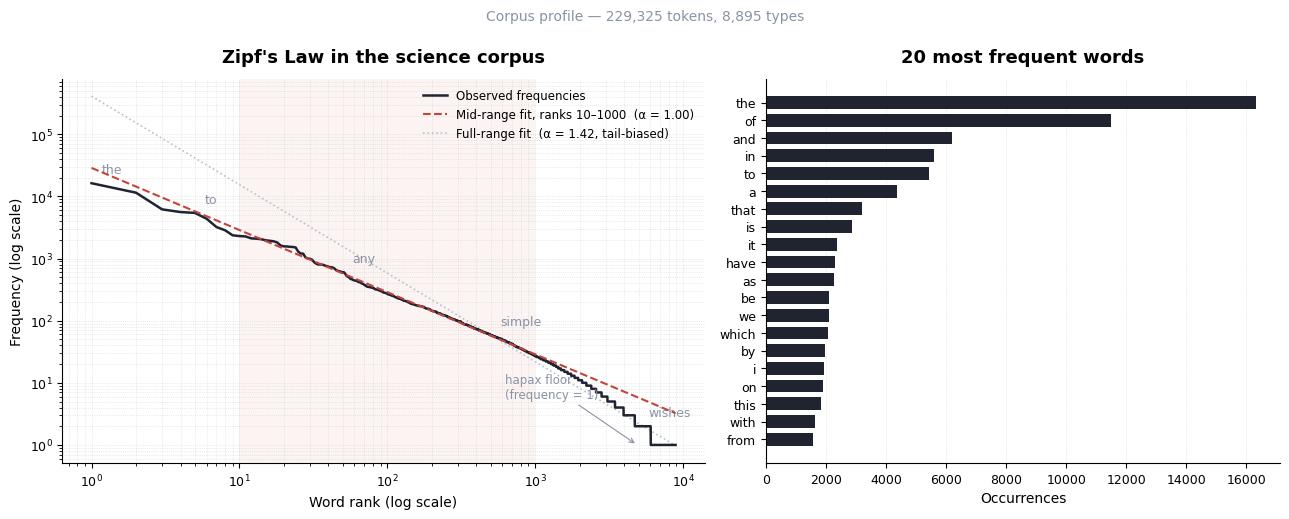

Zipf exponent α (ranks 10–1000) : 1.000   English ≈ 1.0 → consistent with natural language ✓
Zipf exponent α (all ranks)          : 1.424   (steepened by the hapax floor)
Hapax legomena                       : 2,860 words (32.2% of vocabulary)
Figure saved                         → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/figures/zipf_law.png


In [7]:
# ── Zipf's Law validation figure ─────────────────────────────────
import numpy as np

FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

ranked = word_freq.most_common()
freqs  = np.array([c for _, c in ranked], dtype=float)
words  = [w for w, _ in ranked]
ranks  = np.arange(1, len(freqs) + 1, dtype=float)
log_r, log_f = np.log10(ranks), np.log10(freqs)

# Full-range fit (diagnostic — biased by the hapax floor)
alpha_all, icept_all = np.polyfit(log_r, log_f, 1)

# Mid-range fit (standard estimate of the Zipf exponent)
FIT_LO, FIT_HI = 10, min(1000, len(freqs))
mask = (ranks >= FIT_LO) & (ranks <= FIT_HI)
alpha_mid, icept_mid = np.polyfit(log_r[mask], log_f[mask], 1)

hapax = int((freqs == 1).sum())
INK, ACCENT, MUTED, FADE = "#1f2430", "#c2453d", "#8a93a5", "#b9c0cc"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# ── Left: Zipf curve ──
ax1.axvspan(FIT_LO, FIT_HI, color=ACCENT, alpha=0.06, lw=0)
ax1.loglog(ranks, freqs, lw=1.8, color=INK, label="Observed frequencies", zorder=3)
ax1.loglog(ranks, 10**(icept_mid + alpha_mid * log_r), lw=1.5, ls="--", color=ACCENT,
           label=f"Mid-range fit, ranks {FIT_LO}–{FIT_HI}  (α = {abs(alpha_mid):.2f})", zorder=4)
ax1.loglog(ranks, 10**(icept_all + alpha_all * log_r), lw=1.2, ls=":", color=FADE,
           label=f"Full-range fit  (α = {abs(alpha_all):.2f}, tail-biased)", zorder=2)

for i in (0, 4, 49, 499, 4999):
    if i < len(words):
        ax1.annotate(words[i], (ranks[i], freqs[i]), textcoords="offset points",
                     xytext=(7, 7), fontsize=9, color=MUTED)
ax1.annotate("hapax floor\n(frequency = 1)", xy=(ranks[-1] * 0.55, 1),
             xytext=(-95, 34), textcoords="offset points", fontsize=8.5, color=MUTED,
             arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))

ax1.set_xlabel("Word rank (log scale)")
ax1.set_ylabel("Frequency (log scale)")
ax1.set_title("Zipf's Law in the science corpus", fontsize=13, weight="bold", pad=12)
ax1.legend(frameon=False, fontsize=8.5, loc="upper right")
ax1.grid(True, which="both", ls=":", lw=0.5, alpha=0.45)

# ── Right: top 20 words ──
top_w = [w for w, _ in ranked[:20]][::-1]
top_c = [c for _, c in ranked[:20]][::-1]
ax2.barh(top_w, top_c, color=INK, height=0.72)
ax2.set_xlabel("Occurrences")
ax2.set_title("20 most frequent words", fontsize=13, weight="bold", pad=12)
ax2.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(labelsize=9)

fig.suptitle(f"Corpus profile — {n_tokens:,} tokens, {n_types:,} types",
             fontsize=10, color=MUTED, y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "zipf_law.png", dpi=200, bbox_inches="tight")
plt.show()

verdict = "consistent with natural language ✓" if 0.8 <= abs(alpha_mid) <= 1.25 else "unusual — investigate"
print(f"Zipf exponent α (ranks {FIT_LO}–{FIT_HI}) : {abs(alpha_mid):.3f}   English ≈ 1.0 → {verdict}")
print(f"Zipf exponent α (all ranks)          : {abs(alpha_all):.3f}   (steepened by the hapax floor)")
print(f"Hapax legomena                       : {hapax:,} words ({hapax / n_types:.1%} of vocabulary)")
print(f"Figure saved                         → {FIG_DIR / 'zipf_law.png'}")

## 5. Verification and saved artefacts

Every downstream notebook depends on the objects built here, so we verify them
before writing anything to disk. Each check is an assertion — the notebook fails
loudly rather than silently exporting a broken artefact.

### Artefacts written to `data/`

| File | Contents | Consumed by |
|---|---|---|
| `science_corpus.txt` | Cleaned combined corpus | Notebook 03 (language model) |
| `word_freq.json` | Domain word → count | Notebooks 03, 04 (candidate ranking) |
| `dictionary.txt` | Final two-layer vocabulary, one word per line | Notebook 04 (error detection) |
| `misspelling_pairs.json` | misspelling → correction(s) | Notebook 05 (evaluation set) |
| `corpus_metadata.json` | Sources, citations, statistics, filter settings | Report and reproducibility |

A **round-trip test** closes the notebook: each artefact is read back from disk
and compared against the in-memory object, confirming that what the next notebook
will load is exactly what was built here.

In [8]:
# ── Verification ─────────────────────────────────────────────────
checks = []

def check(label, condition, detail=""):
    checks.append((label, bool(condition), detail))

check("Corpus meets 100k-token target", n_tokens >= 100_000, f"{n_tokens:,} tokens")
check("Frequency counts sum to token total", sum(word_freq.values()) == n_tokens,
      f"{sum(word_freq.values()):,}")
check("Vocabulary size matches frequency table", len(word_freq) == n_types, f"{n_types:,} types")
check("Dictionary is substantially larger than corpus vocabulary",
      len(DICTIONARY) > 10 * n_types, f"{len(DICTIONARY):,} words")
check("All dictionary entries are well-formed",
      all(TOKEN_RE.fullmatch(w) for w in list(DICTIONARY)[:50_000]), "sampled 50k entries")
check("Zipf exponent consistent with natural language", 0.8 <= abs(alpha_mid) <= 1.25,
      f"α = {abs(alpha_mid):.3f}")

known_words = ["evolution", "quantum", "combustion", "species", "pizza",
               "keyboard", "jealous", "internet", "photosynthesis"]
check("Valid words accepted (no false positives)",
      all(w in DICTIONARY for w in known_words),
      f"{sum(w in DICTIONARY for w in known_words)}/{len(known_words)}")

typos = ["teh", "recieve", "wich", "thier", "accelertion", "seperate", "definately"]
check("Misspellings rejected", all(t not in DICTIONARY for t in typos),
      f"{sum(t not in DICTIONARY for t in typos)}/{len(typos)}")

check("Evaluation pairs available for later notebooks", len(misspell_pairs) > 1_000,
      f"{len(misspell_pairs):,} pairs")

width = max(len(c[0]) for c in checks)
print("VERIFICATION\n" + "─" * (width + 26))
for label, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label:<{width}}  {detail}")
print("─" * (width + 26))
print(f"  {sum(ok for _, ok, _ in checks)}/{len(checks)} checks passed")

assert all(ok for _, ok, _ in checks), "One or more verification checks failed."

VERIFICATION
───────────────────────────────────────────────────────────────────────────────────
  PASS  Corpus meets 100k-token target                             229,325 tokens
  PASS  Frequency counts sum to token total                        229,325
  PASS  Vocabulary size matches frequency table                    8,895 types
  PASS  Dictionary is substantially larger than corpus vocabulary  369,989 words
  PASS  All dictionary entries are well-formed                     sampled 50k entries
  PASS  Zipf exponent consistent with natural language             α = 1.000
  PASS  Valid words accepted (no false positives)                  9/9
  PASS  Misspellings rejected                                      7/7
  PASS  Evaluation pairs available for later notebooks             4,304 pairs
───────────────────────────────────────────────────────────────────────────────────
  9/9 checks passed


In [9]:
# ── Save artefacts and confirm they reload correctly ─────────────
FREQ_PATH = DATA_DIR / "word_freq.json"
DICT_PATH = DATA_DIR / "dictionary.txt"

FREQ_PATH.write_text(json.dumps(dict(word_freq), indent=0, ensure_ascii=False), encoding="utf-8")
DICT_PATH.write_text("\n".join(sorted(DICTIONARY)), encoding="utf-8")

# Enrich the metadata written earlier with everything learned since
metadata.update({
    "tokenization": {
        "pattern": TOKEN_RE.pattern,
        "lowercased": True,
        "tokens": n_tokens,
        "types": n_types,
        "type_token_ratio": round(n_types / n_tokens, 5),
        "hapax_legomena": hapax,
        "hapax_share": round(hapax / n_types, 4),
    },
    "zipf": {
        "alpha_midrange": round(abs(alpha_mid), 3),
        "fit_range": [FIT_LO, FIT_HI],
        "alpha_fullrange": round(abs(alpha_all), 3),
    },
    "dictionary": {
        "design": "two-layer (domain frequencies + general coverage)",
        "coverage_layer_size": len(coverage_vocab),
        "coverage_layer_source": "dwyl/english-words words_alpha.txt",
        "domain_layer_size": len(domain_vocab),
        "domain_only_kept": len(domain_only_kept),
        "ocr_filtered_out": len(ocr_dropped),
        "min_domain_frequency": MIN_DOMAIN_FREQ,
        "blocklist_size": len(BLOCKLIST),
        "blocklist_source": "Wikipedia: Lists of common misspellings (For machines)",
        "final_size": len(DICTIONARY),
    },
})
META_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

# ── Round-trip test ──
reloaded_freq = json.loads(FREQ_PATH.read_text(encoding="utf-8"))
reloaded_dict = set(DICT_PATH.read_text(encoding="utf-8").split("\n"))
reloaded_meta = json.loads(META_PATH.read_text(encoding="utf-8"))

assert reloaded_freq == dict(word_freq),        "word_freq.json did not round-trip"
assert reloaded_dict == DICTIONARY,             "dictionary.txt did not round-trip"
assert reloaded_meta["tokenization"]["tokens"] == n_tokens, "metadata did not round-trip"

for path in [CORPUS_PATH, FREQ_PATH, DICT_PATH, MISSPELL_PAIRS_PATH, META_PATH]:
    size_mb = path.stat().st_size / 1_048_576
    print(f"  {path.name:<26} {size_mb:>7.2f} MB")

print("\nAll artefacts saved and verified by round-trip reload ✓")

  science_corpus.txt            1.28 MB
  word_freq.json                0.13 MB
  dictionary.txt                3.68 MB
  misspelling_pairs.json        0.14 MB
  corpus_metadata.json          0.00 MB

All artefacts saved and verified by round-trip reload ✓


## Summary

| Property | Value |
|---|---|
| Corpus | 3 public-domain science texts (biology, physics, chemistry) |
| Corpus size | ~229k tokens / ~8.9k types |
| Zipf exponent (ranks 10–1000) | ≈ 1.00 — consistent with natural language |
| Dictionary | Two-layer, ~370k words |
| Noise filters | OCR frequency filter + data-derived misspelling blocklist |

### Design decisions carried forward

1. **Two layers, two jobs.** Existence is decided by the broad coverage layer;
   probability comes from the domain layer. This removes false positives without
   diluting the science-domain ranking.
2. **Filters are data-driven and reversible.** Both the OCR threshold and the
   blocklist derive from external evidence and corpus statistics, and both are
   recorded in `corpus_metadata.json`.
3. **One tokenizer everywhere.** The same `tokenize()` rules must be used by the
   language model, the correction engine, and the application, or detection will
   silently disagree with the dictionary.

### Next: Notebook 02 — Edit Distance

Detection tells us *that* a word is wrong; it does not tell us what was intended.
Notebook 02 builds minimum edit distance to measure how far a typed string is
from each dictionary word, which becomes the basis for candidate generation.